In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv(r"India-Fertility-Rate-Births-per-Woman-2025-10-31-14-09.csv")
data.tail()


,Unnamed: 0,Fertility Rate
71,2021,2.01
72,2022,1.99
73,2023,1.98
74,2024,2.12
75,2025,2.11


In [ ]:
data.shape


(76, 2)

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      76 non-null     int64  
 1   Fertility Rate  76 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.3 KB


In [ ]:
data.isnull().sum()


Unnamed: 0        0
Fertility Rate    0
dtype: int64

In [ ]:
data.columns = ["Year", "Fertility"]


In [ ]:
data.head()


,Year,Fertility
0,1950,5.91
1,1951,5.91
2,1952,5.90
3,1953,5.90
4,1954,5.90


<Axes: xlabel='Year', ylabel='Fertility'>

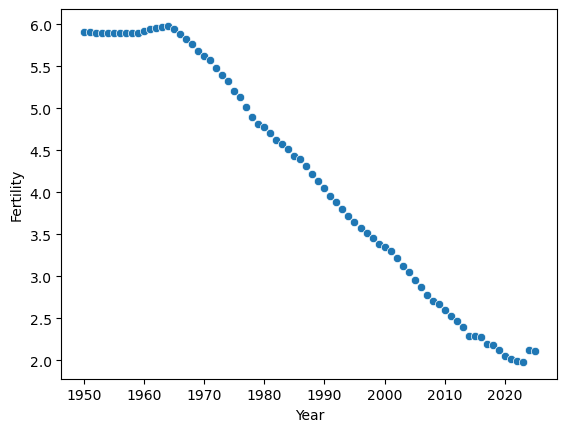

In [ ]:
sns.scatterplot(data=data, x="Year", y="Fertility")


<Axes: >

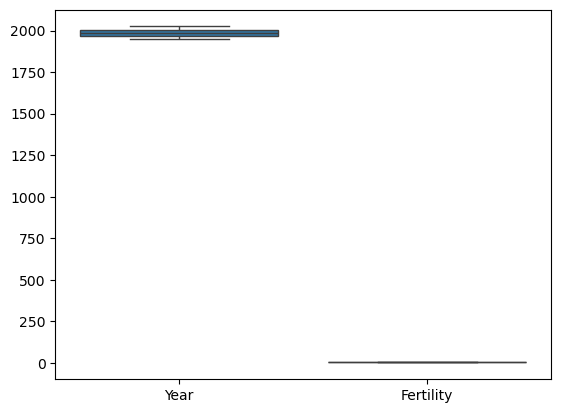

In [ ]:
sns.boxplot(data=data)


In [ ]:
Target_df = data["Fertility"]
Features = data.drop("Fertility", axis=1)


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
train_X, test_X, train_y, test_y = train_test_split(
    Features, Target_df, test_size=0.2, random_state=69
)
print(train_X.shape)
print(train_y.shape)
print(test_X.shape)
print(test_y.shape)


(60, 1)
(60,)
(16, 1)
(16,)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


In [ ]:
model.fit(train_X, train_y)
y_pred = model.predict(test_X)


In [15]:
from sklearn.metrics import mean_squared_error


In [ ]:
mse = mean_squared_error(test_y, y_pred)
print(mse)


0.05260355714197387


In [ ]:
test_X


,Year
31,1981
10,1960
33,1983
40,1990
63,2013
45,1995
48,1998
1,1951
15,1965
59,2009


In [ ]:
y_pred


array([4.61215122, 5.96042983, 4.48374373, 4.03431753, 2.55763144,
       3.71329882, 3.52068759, 6.53826352, 5.63941111, 2.81444641,
       4.2911325 , 2.04400149, 4.80476245, 6.34565229, 3.26387261,
       6.15304106])

In [ ]:
future_years = [x for x in range(2026, 2056)]
future_years = pd.DataFrame(future_years)
future_years.columns = ["Year"]
future_years


,Year
0,2026
1,2027
2,2028
3,2029
4,2030
5,2031
6,2032
7,2033
8,2034
9,2035


In [ ]:
random_predict = model.predict(future_years)
random_predict


array([ 1.72298278,  1.65877903,  1.59457529,  1.53037155,  1.4661678 ,
        1.40196406,  1.33776032,  1.27355657,  1.20935283,  1.14514909,
        1.08094534,  1.0167416 ,  0.95253786,  0.88833412,  0.82413037,
        0.75992663,  0.69572289,  0.63151914,  0.5673154 ,  0.50311166,
        0.43890791,  0.37470417,  0.31050043,  0.24629668,  0.18209294,
        0.1178892 ,  0.05368545, -0.01051829, -0.07472203, -0.13892578])

In [ ]:
prediction_df = pd.DataFrame(columns=["Year", "Fertility"])
prediction_df["Year"] = future_years
prediction_df["Fertility"] = random_predict


<Axes: xlabel='Year', ylabel='Fertility'>

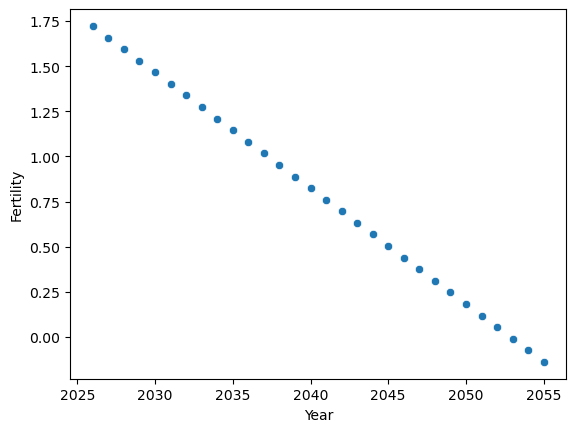

In [ ]:
sns.scatterplot(prediction_df, x=prediction_df["Year"], y=prediction_df["Fertility"])


# Year 2037 
 humans will face fertility crisis